In [3]:
from pyspark.sql import SparkSession

In [4]:

# Start Spark session
spark = SparkSession.builder \
    .appName("NYC Taxi Batch July 2025") \
    .getOrCreate()

In [5]:
# 2. Load NYC Taxi data (update path to your file)
df = spark.read.parquet("/Users/shubhangipanda/Documents/Projects/nyc-taxi-spark/data/raw/yellow_tripdata_2025-07.parquet")


In [6]:
# 3. Check schema
df.printSchema()

root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: long (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- Airport_fee: double (nullable = true)
 |-- cbd_congestion_fee: double (nullable = true)



In [7]:
# 4. Show first 5 rows
df.show(5)

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|Airport_fee|cbd_congestion_fee|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+
|       1| 2025-07-01 00:29:37|  2025-07-01 00:45:30|              1|          7.3|         1|                 N|         138|    

In [8]:

# 5. Row count
print("Total rows:", df.count())


Total rows: 3898963


In [9]:

# 6. Quick stats
df.describe(["trip_distance", "fare_amount", "total_amount"]).show()


+-------+------------------+------------------+------------------+
|summary|     trip_distance|       fare_amount|      total_amount|
+-------+------------------+------------------+------------------+
|  count|           3898963|           3898963|           3898963|
|   mean|7.1047555542320975|18.547692047860266|26.827440152669062|
| stddev| 670.0147514855905|20.071383594139693| 24.27460514817624|
|    min|               0.0|           -1591.3|          -1634.75|
|    max|         397994.37|            2495.0|           5297.87|
+-------+------------------+------------------+------------------+



In [10]:
# 2. Take a 10% random sample (without replacement, reproducible with seed)
df_sample = df.sample(withReplacement=False, fraction=0.1, seed=42)

# 3. Or, if you want exactly N rows (say 1 million), you can do:
df_sample = df.limit(1_000_000)


In [11]:
# Quick check
print("Full dataset count:", df.count())
print("Sample dataset count:", df_sample.count())

df_sample.show(5)

Full dataset count: 3898963
Sample dataset count: 1000000
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|Airport_fee|cbd_congestion_fee|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+
|       1| 2025-07-01 00:29:37|  2025-07-01 00:45:30|              1|   

In [12]:
# -------------------------------
# 1. Data Exploration
# -------------------------------
print("Schema of dataset:")
df_sample.printSchema()

print("Number of rows:", df_sample.count())

print("Show first 5 rows:")
df_sample.show(5, truncate=False)

# Basic statistics
print("Summary statistics:")
df_sample.describe(["fare_amount", "trip_distance"]).show()

# Check for nulls
print("Null values per column:")
from pyspark.sql.functions import col, sum as _sum
df_sample.select([_sum(col(c).isNull().cast("int")).alias(c) for c in df_sample.columns]).show()


# -------------------------------
# 2. Data Cleaning
# -------------------------------
from pyspark.sql.functions import col

# Filter invalid rows
df_clean = df_sample.filter(
    (col("fare_amount") > 0) & 
    (col("trip_distance") > 0) & 
    (col("passenger_count") > 0)
)

print("Rows before cleaning:", df_sample.count())
print("Rows after cleaning:", df_clean.count())

# Show a few cleaned rows
df_clean.show(5, truncate=False)


Schema of dataset:
root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: long (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- Airport_fee: double (nullable = true)
 |-- cbd_congestion_fee: double (nullable = true)

Number of rows: 1000000
Show first 5 rows:
+--------+---

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|Airport_fee|cbd_congestion_fee|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+
|       0|                   0|                    0|              0|            0|         0|                 0|           0|    

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|Airport_fee|cbd_congestion_fee|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+
|1       |2025-07-01 00:29:37 |2025-07-01 00:45:30  |1              |7.3          |1         |N                 |138         |74  

In [13]:
# -------------------------------
# 3. Feature Engineering
# -------------------------------
from pyspark.sql.functions import col, hour, dayofweek, unix_timestamp

# Convert pickup/dropoff datetime strings to Spark timestamps
df_feat = df_clean \
    .withColumn("pickup_datetime", col("tpep_pickup_datetime").cast("timestamp")) \
    .withColumn("dropoff_datetime", col("tpep_dropoff_datetime").cast("timestamp"))

# Extract useful time features
df_feat = df_feat \
    .withColumn("pickup_hour", hour(col("pickup_datetime"))) \
    .withColumn("pickup_dayofweek", dayofweek(col("pickup_datetime")))  # 1=Sunday, 7=Saturday

# Compute trip duration in minutes
df_feat = df_feat.withColumn(
    "trip_duration",
    (unix_timestamp("dropoff_datetime") - unix_timestamp("pickup_datetime")) / 60
)

# Remove trips with invalid duration
df_feat = df_feat.filter((col("trip_duration") > 1) & (col("trip_duration") < 180))

print("Final feature-engineered dataset sample:")
df_feat.select("fare_amount", "trip_distance", "passenger_count",
               "pickup_hour", "pickup_dayofweek", "trip_duration").show(5, truncate=False)


Final feature-engineered dataset sample:
+-----------+-------------+---------------+-----------+----------------+------------------+
|fare_amount|trip_distance|passenger_count|pickup_hour|pickup_dayofweek|trip_duration     |
+-----------+-------------+---------------+-----------+----------------+------------------+
|29.6       |7.3          |1              |0          |3               |15.883333333333333|
|70.0       |17.7         |1              |0          |3               |44.266666666666666|
|43.6       |9.98         |1              |0          |3               |33.36666666666667 |
|38.7       |10.27        |1              |0          |3               |17.1              |
|17.0       |2.94         |1              |0          |3               |14.533333333333333|
+-----------+-------------+---------------+-----------+----------------+------------------+
only showing top 5 rows


In [14]:
# -----------------------------
# 3. Clean Fare, Tip, and Total Amounts
# -----------------------------

# Keep only valid fare amounts ( > 0 and < 500 )
df = df.filter((df.fare_amount > 0) & (df.fare_amount < 500))

# Keep only valid tip amounts ( >= 0, no negative tips )
df = df.filter(df.tip_amount >= 0)

# Remove invalid total_amount (should always be >= fare_amount + tip_amount)
df = df.filter(df.total_amount >= (df.fare_amount + df.tip_amount))

print("After cleaning fare, tip, and total amounts:", df.count())


After cleaning fare, tip, and total amounts: 3650328


In [15]:
# Keep only realistic passenger counts (1 to 6)
df = df.filter((df.passenger_count >= 1) & (df.passenger_count <= 6))

print("After cleaning fare, tip, total, and passenger count:", df.count())

After cleaning fare, tip, total, and passenger count: 2762242


In [16]:
from pyspark.sql.functions import hour, dayofweek

# Extract pickup hour (0–23) and pickup day of week (1=Sunday, 7=Saturday)
df = df.withColumn("pickup_hour", hour("tpep_pickup_datetime"))
df = df.withColumn("pickup_dayofweek", dayofweek("tpep_pickup_datetime"))

# Quick check
df.select("tpep_pickup_datetime", "pickup_hour", "pickup_dayofweek").show(5, truncate=False)


+--------------------+-----------+----------------+
|tpep_pickup_datetime|pickup_hour|pickup_dayofweek|
+--------------------+-----------+----------------+
|2025-07-01 00:29:37 |0          |3               |
|2025-07-01 00:23:28 |0          |3               |
|2025-07-01 00:53:50 |0          |3               |
|2025-07-01 00:58:49 |0          |3               |
|2025-07-01 00:09:22 |0          |3               |
+--------------------+-----------+----------------+
only showing top 5 rows


In [17]:
from pyspark.sql.functions import count

# Group by pickup hour and count trips
hourly_trips = df.groupBy("pickup_hour").agg(count("*").alias("trip_count"))

# Show results sorted by hour
hourly_trips.orderBy("pickup_hour").show(24)


+-----------+----------+
|pickup_hour|trip_count|
+-----------+----------+
|          0|     72307|
|          1|     46974|
|          2|     29317|
|          3|     18245|
|          4|     12558|
|          5|     16818|
|          6|     37094|
|          7|     69835|
|          8|     98719|
|          9|    118230|
|         10|    130304|
|         11|    141065|
|         12|    155363|
|         13|    163373|
|         14|    172899|
|         15|    176187|
|         16|    178796|
|         17|    192163|
|         18|    197971|
|         19|    176266|
|         20|    158539|
|         21|    157872|
|         22|    138936|
|         23|    102411|
+-----------+----------+



In [18]:
from pyspark.sql.functions import avg

# Average trip distance by pickup hour
avg_distance_by_hour = df.groupBy("pickup_hour").agg(avg("trip_distance").alias("avg_trip_distance"))

# Show results sorted by hour
avg_distance_by_hour.orderBy("pickup_hour").show(24)


+-----------+------------------+
|pickup_hour| avg_trip_distance|
+-----------+------------------+
|          0| 4.981542312639189|
|          1| 4.396225145825372|
|          2|3.8368554081249724|
|          3|3.7524746505892024|
|          4| 5.046692944736421|
|          5|6.1770674277559685|
|          6| 4.616328786326626|
|          7|3.7821358917448142|
|          8|3.2599310163190443|
|          9| 3.111677408441182|
|         10|3.1232317503683746|
|         11| 3.133919186190771|
|         12| 3.198677677439278|
|         13|3.2695004682536246|
|         14| 3.490295201244648|
|         15|3.5104318706828193|
|         16| 3.496905355824507|
|         17| 3.249278893439426|
|         18| 3.050784306792434|
|         19|3.1904264577400023|
|         20|3.4917680192255482|
|         21| 3.507192789094958|
|         22|  3.80597454943285|
|         23| 4.363400123033676|
+-----------+------------------+



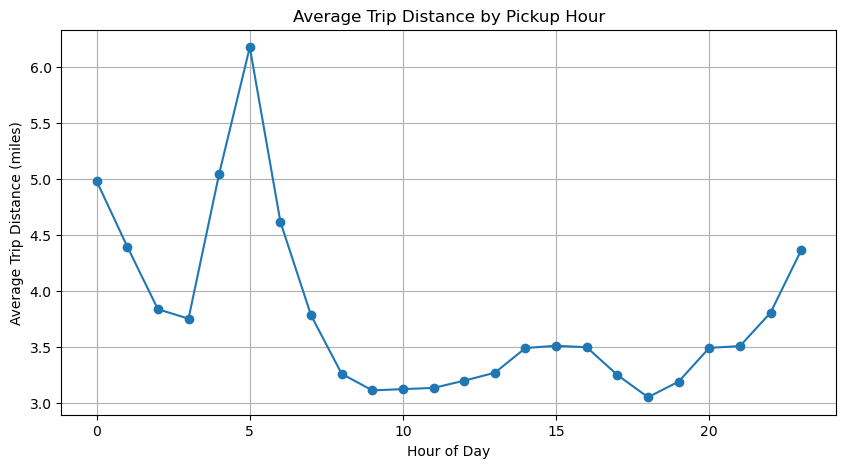

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# Collect Spark results into Pandas
avg_distance_pd = avg_distance_by_hour.orderBy("pickup_hour").toPandas()

# Plot
plt.figure(figsize=(10,5))
plt.plot(avg_distance_pd["pickup_hour"], avg_distance_pd["avg_trip_distance"], marker="o")
plt.title("Average Trip Distance by Pickup Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Trip Distance (miles)")
plt.grid(True)
plt.show()


In [20]:
# ⚠️ NOTE on using .toPandas():
# 
# - The method .toPandas() collects Spark DataFrame results into Pandas.
# - This is fine for small/medium datasets (like our sample).
# - BUT ⚠️ do not use .toPandas() on very large datasets 
#   (e.g., full NYC Taxi data with millions of rows), 
#   as it will try to load all data into driver memory and can crash.
#
# ✅ Best practice:
#   - Use .toPandas() only after aggregations (e.g., groupBy results).
#   - For large data, stick to Spark DataFrame operations and visualize with Spark-compatible tools.


In [21]:
# Extract pickup hour
from pyspark.sql.functions import hour, col

In [22]:
taxi_df = df


In [23]:
avg_fare_by_hour = taxi_df.withColumn("pickup_hour", hour(col("tpep_pickup_datetime"))) \
    .groupBy("pickup_hour") \
    .agg({"fare_amount": "avg"}) \
    .withColumnRenamed("avg(fare_amount)", "avg_fare")


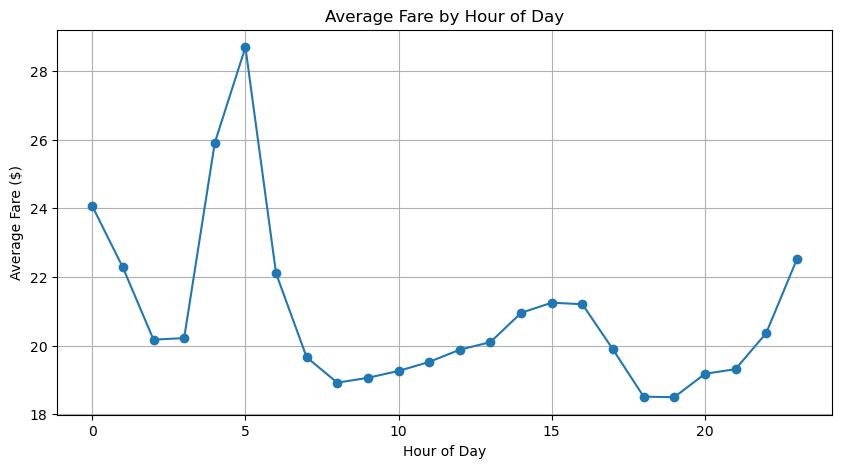

In [24]:

# Collect into Pandas for visualization
avg_fare_pd = avg_fare_by_hour.orderBy("pickup_hour").toPandas()

# Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(avg_fare_pd["pickup_hour"], avg_fare_pd["avg_fare"], marker="o")
plt.title("Average Fare by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average Fare ($)")
plt.grid(True)
plt.show()

In [26]:
from pyspark.sql import functions as F

# Average fare by passenger count
avg_fare_by_passenger = taxi_df.groupBy("passenger_count") \
    .agg(F.avg("fare_amount").alias("avg_fare")) \
    .orderBy("passenger_count")

# Show results
avg_fare_by_passenger.show()

+---------------+------------------+
|passenger_count|          avg_fare|
+---------------+------------------+
|              1|19.242164482656538|
|              2|22.921013237478654|
|              3|  23.7587545184352|
|              4| 28.13473305791695|
|              5|17.501614157285175|
|              6| 17.90573707805906|
+---------------+------------------+



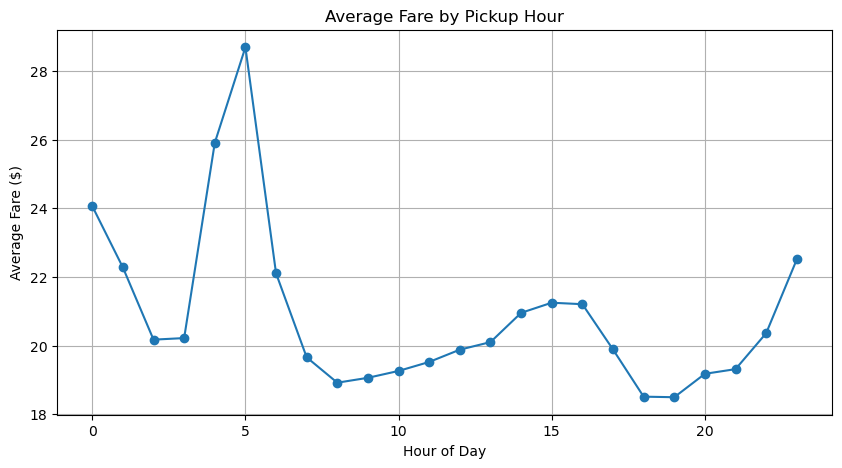

In [27]:
# Average fare by pickup hour

# Group by pickup hour and calculate average fare
avg_fare_by_hour = taxi_df.groupBy("pickup_hour").agg(
    F.avg("fare_amount").alias("avg_fare")
)

# Convert to Pandas for plotting
avg_fare_pd = avg_fare_by_hour.orderBy("pickup_hour").toPandas()

# Plot
plt.figure(figsize=(10,5))
plt.plot(avg_fare_pd["pickup_hour"], avg_fare_pd["avg_fare"], marker='o')
plt.title("Average Fare by Pickup Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Fare ($)")
plt.grid(True)
plt.show()


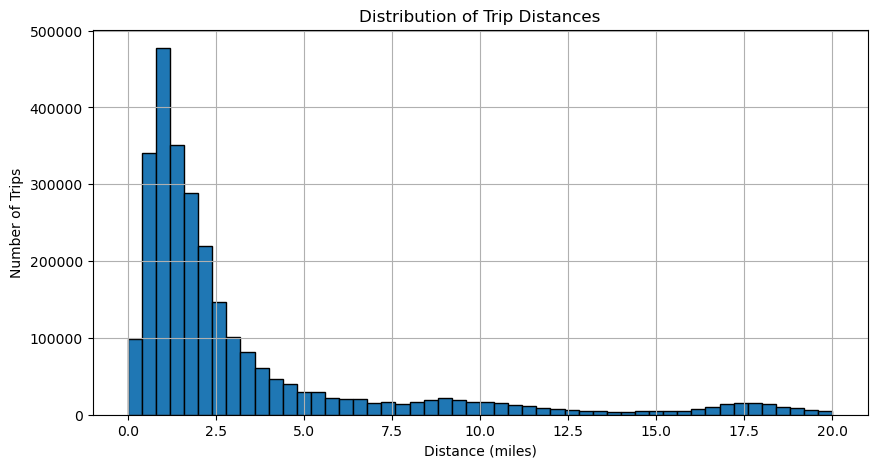

In [28]:
# Trip distance distribution

# Collect trip distances into Pandas
trip_distance_pd = taxi_df.select("trip_distance").toPandas()

# Plot histogram
plt.figure(figsize=(10,5))
plt.hist(trip_distance_pd["trip_distance"], bins=50, range=(0, 20), edgecolor='black')
plt.title("Distribution of Trip Distances")
plt.xlabel("Distance (miles)")
plt.ylabel("Number of Trips")
plt.grid(True)
plt.show()


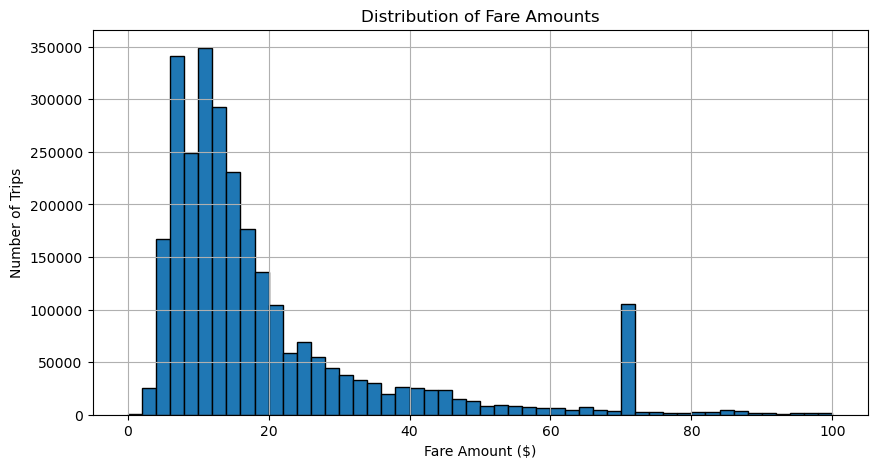

In [29]:
# Fare distribution

# Collect fare amounts into Pandas
fare_pd = taxi_df.select("fare_amount").toPandas()

# Plot histogram
plt.figure(figsize=(10,5))
plt.hist(fare_pd["fare_amount"], bins=50, range=(0, 100), edgecolor='black')
plt.title("Distribution of Fare Amounts")
plt.xlabel("Fare Amount ($)")
plt.ylabel("Number of Trips")
plt.grid(True)
plt.show()


In [31]:
# Pickup hotspots visualization

# Collect a sample of pickup coordinates
pickup_pd = taxi_df.select("pickup_longitude", "pickup_latitude").sample(False, 0.001).toPandas()



{"ts": "2025-09-02 03:37:12.561", "level": "ERROR", "logger": "DataFrameQueryContextLogger", "msg": "[UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `pickup_longitude` cannot be resolved. Did you mean one of the following? [`pickup_hour`, `pickup_dayofweek`, `tip_amount`, `Airport_fee`, `fare_amount`]. SQLSTATE: 42703", "context": {"file": "jdk.internal.reflect.GeneratedMethodAccessor53.invoke(Unknown Source)", "line": "", "fragment": "col", "errorClass": "UNRESOLVED_COLUMN.WITH_SUGGESTION"}, "exception": {"class": "Py4JJavaError", "msg": "An error occurred while calling o333.select.\n: org.apache.spark.sql.AnalysisException: [UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `pickup_longitude` cannot be resolved. Did you mean one of the following? [`pickup_hour`, `pickup_dayofweek`, `tip_amount`, `Airport_fee`, `fare_amount`]. SQLSTATE: 42703;\n'Project ['pickup_longitude, 'pickup_latitude]\n+- Project [Vendo

AnalysisException: [UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `pickup_longitude` cannot be resolved. Did you mean one of the following? [`pickup_hour`, `pickup_dayofweek`, `tip_amount`, `Airport_fee`, `fare_amount`]. SQLSTATE: 42703;
'Project ['pickup_longitude, 'pickup_latitude]
+- Project [VendorID#0, tpep_pickup_datetime#1, tpep_dropoff_datetime#2, passenger_count#3L, trip_distance#4, RatecodeID#5L, store_and_fwd_flag#6, PULocationID#7, DOLocationID#8, payment_type#9L, fare_amount#10, extra#11, mta_tax#12, tip_amount#13, tolls_amount#14, improvement_surcharge#15, total_amount#16, congestion_surcharge#17, Airport_fee#18, cbd_congestion_fee#19, pickup_hour#940, dayofweek(cast(tpep_pickup_datetime#1 as date)) AS pickup_dayofweek#941]
   +- Project [VendorID#0, tpep_pickup_datetime#1, tpep_dropoff_datetime#2, passenger_count#3L, trip_distance#4, RatecodeID#5L, store_and_fwd_flag#6, PULocationID#7, DOLocationID#8, payment_type#9L, fare_amount#